In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
telco_data = pd.read_csv('../data/churn_cleaned.csv')
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Data Cleaning

In [39]:
telco_data.drop(columns=["customerID","ChurnFlag"],inplace = True)
telco_data["Churn"] = telco_data["Churn"].map({"Yes": 1, "No": 0})

In [12]:
max(telco_data['tenure'])

72

In [40]:
def tenure_bucket(t):
    if t <= 12:
        return "0-1yr"
    elif t <= 24:
        return "1-2yr"
    elif t <= 48:
        return "2-4yr"
    elif t<= 72:
        return "4-6yr"

telco_data["TenureGroup"] = telco_data["tenure"].apply(tenure_bucket)
telco_data["AvgMonthlySpend"] = np.where(telco_data["tenure"] > 0, telco_data["TotalCharges"] / telco_data["tenure"], telco_data["MonthlyCharges"])

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
telco_data["NumAddOnServices"] = telco_data[service_cols].apply(lambda row: sum(v == "Yes" for v in row), axis=1)
telco_data["HasInternet"] = (telco_data["InternetService"] != "No").astype(int)

In [41]:
telco_data.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,NumAddOnServices,HasInternet
4163,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Two year,No,Bank transfer (automatic),115.15,8349.45,0,4-6yr,115.964583,6,1
5532,Female,0,No,No,61,Yes,Yes,Fiber optic,No,No,...,Two year,Yes,Electronic check,106.60,6428.40,1,4-6yr,105.383607,4,1
4354,Male,0,No,No,29,Yes,No,DSL,Yes,Yes,...,One year,Yes,Electronic check,58.75,1696.20,0,2-4yr,58.489655,3,1
3163,Female,0,No,No,50,Yes,No,No,No internet service,No internet service,...,One year,Yes,Mailed check,19.35,1033.00,0,4-6yr,20.660000,0,0
3275,Male,0,Yes,No,55,Yes,No,DSL,Yes,Yes,...,Two year,No,Electronic check,58.60,3068.60,0,4-6yr,55.792727,3,1


## Correlation between new columns

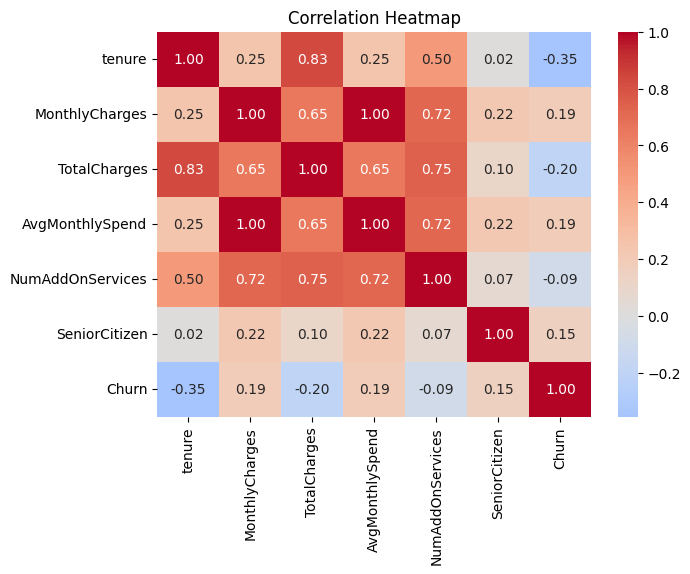

In [42]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "NumAddOnServices", "SeniorCitizen", "Churn"]
plt.figure(figsize=(7,5))
sns.heatmap(telco_data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [44]:
telco_data.to_csv("../data/churn_cleaned.csv", index=False)